In [1]:
from pytential.sympy_pytential import sympy_pytential
from pytential.reduce import min_pytential
import numpy as np
from sympy import log, symbols
import matplotlib.pyplot as plt

This file demonstrates how to create, combine, and manipulate pytentials.  Equibilriation is used to reduce free variables. 

# Create phases

Create two binary ideal solutions

In [2]:
c0a, c1a, c0b, c1b, Va, Vb = symbols('c0a, c1a, c0b, c1b, Va, Vb')

In [3]:
RT = 8.134*300
fa_sp = c0a*RT*(1+log(c0a/(c0a+c1a))) +c1a*RT*(0+log(c1a/(c0a+c1a)))
fb_sp = c0b*RT*(0+log(c0b/(c0b+c1b))) +c1b*RT*(1+log(c1b/(c0b+c1b)))

In [4]:
fa = sympy_pytential(fa_sp, constraints_sym=[c0a+c1a-Va])
fb = sympy_pytential(fb_sp, constraints_sym=[c0b+c1b-Vb])
print('fa:', fa)

fa: x = ['Va', 'c0a', 'c1a']

f(x) = 2440.2*c0a*(log(c0a/(c0a + c1a)) + 1) + 2440.2*c1a*log(c1a/(c0a + c1a))

f'(x)= [0, 2440.2*log(c0a/(c0a + c1a)) + 2440.2, 2440.2*log(c1a/(c0a + c1a))]

f"(x)= [[0, 0, 0], [0, 2440.2*c1a/(c0a*(c0a + c1a)), -2440.2/(c0a + c1a)], [0, -2440.2/(c0a + c1a), 2440.2*c0a/(c1a*(c0a + c1a))]]

Constraints:
0 = -Va + c0a + c1a



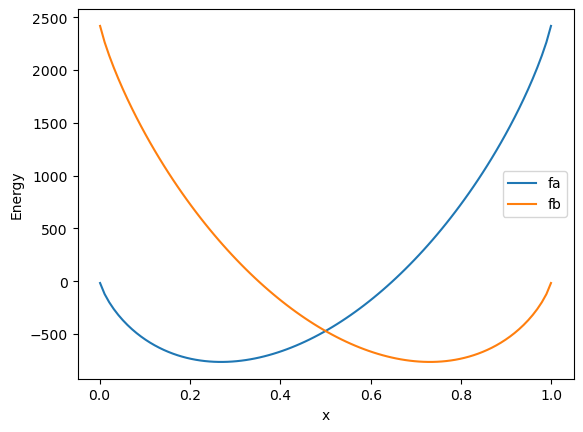

In [5]:
x_values = np.linspace(0.001, .999, 100)
ya = fa(c0a=x_values, c1a=1-x_values, Va = 1)
yb = fb(c0b=x_values, c1b=1-x_values, Vb = 1)

plt.plot(x_values, ya, label='fa')
plt.plot(x_values, yb, label='fb')
plt.xlabel('x')
plt.ylabel('Energy')
plt.legend()
plt.show()

# Combine functions

Combine functions into a composite pytential

In [6]:
f = fa+fb
print(f)

x = ['Va', 'Vb', 'c0a', 'c0b', 'c1a', 'c1b']

f(x) = 2440.2*c0a*(log(c0a/(c0a + c1a)) + 1) + 2440.2*c0b*log(c0b/(c0b + c1b)) + 2440.2*c1a*log(c1a/(c0a + c1a)) + 2440.2*c1b*(log(c1b/(c0b + c1b)) + 1)

f'(x)= [0, 0, 2440.2*log(c0a/(c0a + c1a)) + 2440.2, 2440.2*log(c0b/(c0b + c1b)), 2440.2*log(c1a/(c0a + c1a)), 2440.2*log(c1b/(c0b + c1b)) + 2440.2]

f"(x)= [[0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 0, 2440.2*c1a/(c0a*(c0a + c1a)), 0, -2440.2/(c0a + c1a), 0], [0, 0, 0, 2440.2*c1b/(c0b*(c0b + c1b)), 0, -2440.2/(c0b + c1b)], [0, 0, -2440.2/(c0a + c1a), 0, 2440.2*c0a/(c1a*(c0a + c1a)), 0], [0, 0, 0, -2440.2/(c0b + c1b), 0, 2440.2*c0b/(c1b*(c0b + c1b))]]

Constraints:
0 = -Va + c0a + c1a
-Vb + c0b + c1b



Add a constraint for the total x. Note the function is now an argument of x1, x2, and x

In [7]:
c0, c1 = symbols('c0, c1')
f_constrained = f.add_constraints_sym([c0a+c0b-c0, c1a+c1b-c1]) 
print(f_constrained)

x = ['Va', 'Vb', 'c0', 'c0a', 'c0b', 'c1', 'c1a', 'c1b']

f(x) = 2440.2*c0a*(log(c0a/(c0a + c1a)) + 1) + 2440.2*c0b*log(c0b/(c0b + c1b)) + 2440.2*c1a*log(c1a/(c0a + c1a)) + 2440.2*c1b*(log(c1b/(c0b + c1b)) + 1)

f'(x)= [0, 0, 0, 2440.2*log(c0a/(c0a + c1a)) + 2440.2, 2440.2*log(c0b/(c0b + c1b)), 0, 2440.2*log(c1a/(c0a + c1a)), 2440.2*log(c1b/(c0b + c1b)) + 2440.2]

f"(x)= [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 2440.2*c1a/(c0a*(c0a + c1a)), 0, 0, -2440.2/(c0a + c1a), 0], [0, 0, 0, 0, 2440.2*c1b/(c0b*(c0b + c1b)), 0, 0, -2440.2/(c0b + c1b)], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, -2440.2/(c0a + c1a), 0, 0, 2440.2*c0a/(c1a*(c0a + c1a)), 0], [0, 0, 0, 0, -2440.2/(c0b + c1b), 0, 0, 2440.2*c0b/(c1b*(c0b + c1b))]]

Constraints:
0 = -Va + c0a + c1a
-Vb + c0b + c1b
-c0 + c0a + c0b
-c1 + c1a + c1b



In [10]:
f_min = min_pytential(f_constrained, ['c0', 'c1'])
x_values2 = np.linspace(0.0001, .9999, 50)
ym = f_min(c0=x_values2, c1=1-x_values2)
print(ym)

[-1.76598129e-01 -1.93966314e+02 -3.17005558e+02 -4.13002225e+02
 -4.91026375e+02 -5.55379154e+02 -6.08585639e+02 -6.52302052e+02
 -6.87701634e+02 -7.15650586e+02 -7.36814170e+02 -7.51716259e+02
 -7.60777551e+02 -7.64340962e+02 -7.64421170e+02 -7.64421170e+02
 -7.64421170e+02 -7.64421170e+02 -7.64421170e+02 -7.64421170e+02
 -7.64421170e+02 -7.64421170e+02 -7.64421170e+02 -7.64421170e+02
 -7.64421170e+02 -7.64421170e+02 -7.64421170e+02 -7.64421170e+02
 -7.64421170e+02 -7.64421170e+02 -7.64421170e+02 -7.64421170e+02
 -7.64421170e+02 -7.64421170e+02 -7.64421170e+02 -7.64421170e+02
 -7.64340885e+02 -7.60777551e+02 -7.51716259e+02 -7.36814167e+02
 -7.15650586e+02 -6.87701634e+02 -6.52302052e+02 -6.08584740e+02
 -5.55379154e+02 -4.91026375e+02 -4.13002225e+02 -3.17005558e+02
 -1.93966314e+02 -2.22839034e+00]


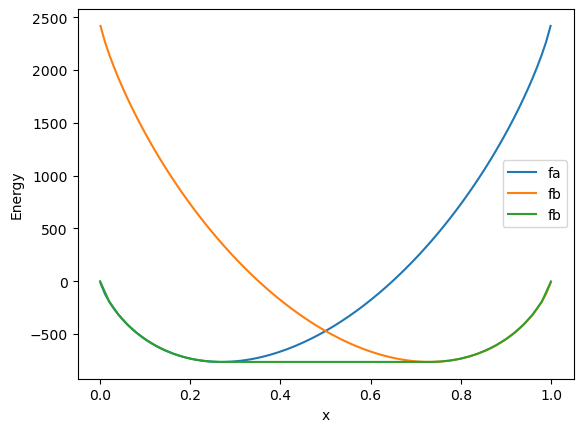

In [11]:
plt.plot(x_values, ya, label='fa')
plt.plot(x_values, yb, label='fb')
plt.plot(x_values2, ym, label='fb')
plt.xlabel('x')
plt.ylabel('Energy')
plt.legend()
plt.show()